# Phase 1: Environment & Data Loading

In this step, we prepare the Python environment and bring the raw data into a structure we can manipulate.

## 1.1 Python Imports

We start by importing the libraries that will do the heavy lifting.

In [1]:
# pandas: The industry standard for data manipulation (think of it as Excel for Python).
import pandas as pd

# matplotlib & seaborn: These are used for data visualization (charts and graphs).
import matplotlib.pyplot as plt
import seaborn as sns

# os: This allows Python to interact with your Ubuntu file system.
import os

## 1.2 Loading the Dataset

We use read_csv to open the file. Note the encoding parameter; standard text is usually UTF-8, but this specific dataset was saved in an older format called latin-1.

In [3]:
# Load the dataset from your local directory.
# We use encoding='latin-1' because the file contains special characters that standard UTF-8 can't read.
df = pd.read_csv('../data/spam.csv', encoding='latin-1')

# Display the first 5 rows to see what the raw data looks like.
print("--- Raw Data Preview ---")
print(df.head())

--- Raw Data Preview ---
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


# Phase 2: Data Wrangling (Cleaning the Structure)

Before we clean the text, we must clean the table. Raw datasets often have "ghost columns" (empty columns) or confusing names.

## 2.1 Removing "Ghost" Columns

We notice that the dataset includes three empty columns (Unnamed: 2, 3, and 4) due to commas in the original text messages. We must drop them.

In [4]:
# The 'drop' function removes columns we don't need. 
# axis=1 tells Pandas to look at columns, not rows.
# inplace=True makes the change directly to our 'df' variable.
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)

# Rename the columns to something logical. 
# 'v1' becomes 'label' (our target) and 'v2' becomes 'text' (our input).
df.rename(columns={'v1': 'label', 'v2': 'text'}, inplace=True)

print("\n--- Cleaned Column Names ---")
print(df.head())


--- Cleaned Column Names ---
  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


## 2.2 Handling Categorical Data (Label Encoding)

Machine learning models cannot read the words "spam" or "ham." They only understand numbers. We will convert these labels into $0$ and $1$.

In [5]:
# We map 'ham' to 0 and 'spam' to 1.
# 0 usually represents the "normal" class, and 1 represents the "anomaly" or target class.
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

print("\n--- Labels Converted to Numbers ---")
print(df[['label', 'label_num']].head())


--- Labels Converted to Numbers ---
  label  label_num
0   ham          0
1   ham          0
2  spam          1
3   ham          0
4   ham          0


# Phase 3: Exploratory Data Analysis (EDA)

This fulfills Step 2 (Developing a Strategy) of your assessment. We need to "see" the data to understand the challenges.

## 3.1 Visualizing Class Imbalance

We need to know if we have enough spam examples to train the model.

/tmp/ipykernel_755334/3461309764.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


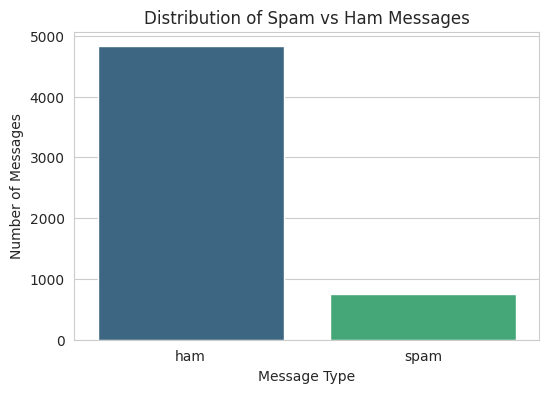


--- Class Percentages ---
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


In [6]:
# Set the visual style of our charts.
sns.set_style('whitegrid')

# Create a count plot to see the distribution of Ham vs Spam.
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribution of Spam vs Ham Messages')
plt.xlabel('Message Type')
plt.ylabel('Number of Messages')
plt.show()

# Calculate the exact percentages for the report.
print("\n--- Class Percentages ---")
print(df['label'].value_counts(normalize=True) * 100)

# Phase 4: Text Pre-processing

In NLP, raw text is "noisy." To help the model find patterns, we must standardize the text. This involves converting to lowercase, removing punctuation, and removing "stopwords" (common words like 'the' or 'is' that don't help classify spam).

## 4.1 Installing NLTK Resources

We use the Natural Language Toolkit (NLTK). Since we are in a new virtual environment, we must download the specific word lists required for cleaning.

In [14]:
import os
import nltk
from nltk.corpus import stopwords

# We point to the parent directory (..) because the venv is in the project root, 
# not inside the notebooks folder.
venv_nltk_path = os.path.abspath('../venv/nltk_data')
os.environ['NLTK_DATA'] = venv_nltk_path

# Add the path to nltk's search list just to be safe
if venv_nltk_path not in nltk.data.path:
    nltk.data.path.append(venv_nltk_path)

try:
    stop_words = set(stopwords.words('english'))
    print("NLTK Data loaded successfully!")
    print(f"Sample stopwords: {list(stop_words)[:5]}")
except LookupError:
    print(f"Error: NLTK could not find data at {venv_nltk_path}")

NLTK Data loaded successfully!
Sample stopwords: ['itself', 'shan', "he's", 'at', 'ours']


## 4.2 Defining the Text Cleaning Function

To ensure consistency and provide a clear audit trail for the analysis, we create a reusable function. This function performs a sequence of three standard NLP tasks:

1. **Case Normalization:** Converts all text to lowercase so the model doesn't treat "WIN" and "win" as different words.

2. **Punctuation Removal:** Strips characters that do not contribute to the semantic meaning of a spam message.

3. **Stopword Filtering:** Removes common English words (e.g., "the", "is", "in") that appear frequently in both spam and ham, thus reducing "noise" in the dataset.

In [17]:
import string

def clean_text(text):
    """
    Standardizes text by:
    1. Converting to lowercase
    2. Removing punctuation
    3. Removing stopwords
    """
    # Lowercase
    text = text.lower()
    
    # Remove punctuation: we keep only characters that are NOT in string.punctuation
    text = "".join([char for char in text if char not in string.punctuation])
    
    # Split into words, filter out stopwords, and join back into a string
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    
    return " ".join(filtered_words)

# Apply the cleaning function to create a new column
df['clean_text'] = df['text'].apply(clean_text)

print("--- Comparison: Original vs. Cleaned ---")
print(df[['text', 'clean_text']].head())

--- Comparison: Original vs. Cleaned ---
                                                text  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                          clean_text  
0  go jurong point crazy available bugis n great ...  
1                            ok lar joking wif u oni  
2  free entry 2 wkly comp win fa cup final tkts 2...  
3                u dun say early hor u c already say  
4        nah dont think goes usf lives around though  


## 4.3 Feature Engineering: Message Length Analysis

Beyond the words themselves, metadata like the length of a message can be a strong predictor. In this step, we calculate the character count for each message to see if there is a statistically significant difference between the two classes. This provides a "Secondary Feature" that can be used to justify model behavior later in the report.

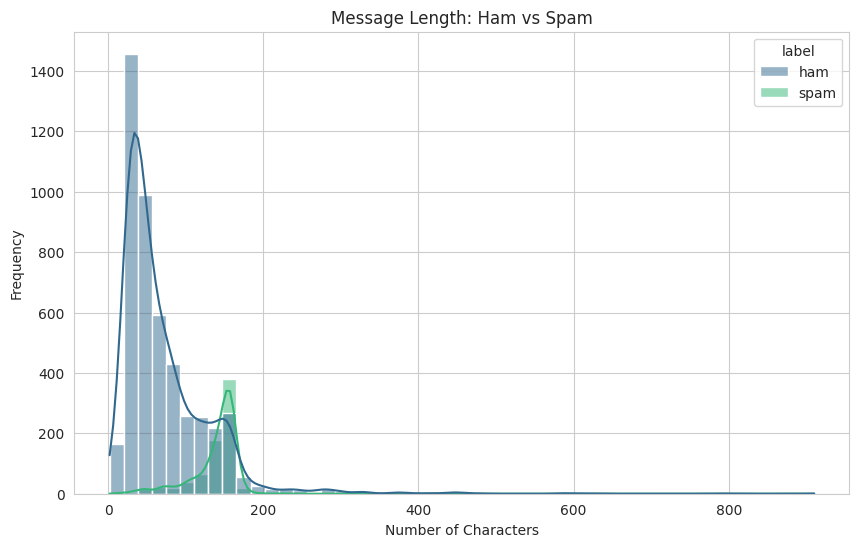


--- Descriptive Statistics for Message Length ---
        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4825.0   71.023627  58.016023   2.0   33.0   52.0   92.0  910.0
spam    747.0  138.866131  29.183082  13.0  132.5  149.0  157.0  224.0


In [18]:
# Create a column representing the character count of the original message
df['text_len'] = df['text'].apply(len)

# Visualize the distribution of lengths
plt.figure(figsize=(10, 6))
# Using 'hue' to separate labels and 'kde=True' to show the density curve
sns.histplot(data=df, x='text_len', hue='label', bins=50, kde=True, palette='viridis')

plt.title('Message Length: Ham vs Spam')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
# Using legend=True to clearly identify the classes in the report
plt.show()

# Quick statistical summary of length by category
print("\n--- Descriptive Statistics for Message Length ---")
print(df.groupby('label')['text_len'].describe())

# Phase 5: Exporting Cleaned Data

To maintain a modular workflow, we save the processed dataset to a new CSV file. This ensures that our machine learning phase starts with a consistent, cleaned input.

In [19]:
# Save the cleaned DataFrame to the 'data' folder
# We set index=False so we don't save the row numbers as a separate column
df.to_csv('../data/spam_cleaned.csv', index=False)

print("File saved successfully to ../data/spam_cleaned.csv")
# Final check of the data structure
print(df.info())

File saved successfully to ../data/spam_cleaned.csv
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   label       5572 non-null   str  
 1   text        5572 non-null   str  
 2   label_num   5572 non-null   int64
 3   clean_text  5572 non-null   str  
 4   text_len    5572 non-null   int64
dtypes: int64(2), str(3)
memory usage: 217.8 KB
None
